In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

projectPath = Path.cwd().parents[1]
print(projectPath)

c:\Users\HannesNikulski\projects\paper-revision


In [14]:
def plotClusters(labels, sliceMatrix, title):
    x = np.arange(sliceMatrix.shape[1])

    clusters = np.sort(np.unique(labels))
    n_clusters = len(clusters)

    n_cols = min(3, n_clusters)
    n_rows = int(np.ceil(n_clusters / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        sharex=True,
        # sharey=True
    )

    axes = np.atleast_1d(axes).flatten()

    for ax, cluster in zip(axes, clusters):
        cluster_data = sliceMatrix[labels == cluster]
        if len(cluster_data) == 0:
            ax.set_title(f"Cluster {cluster} (empty)")
            continue
        
        mean = np.nanmean(cluster_data, axis=0)
        std = np.nanstd(cluster_data, axis=0)

        # if show_individual:
        #     for curve in cluster_data:
        #         ax.plot(x, curve, alpha=0.1)

        ax.fill_between(x, mean - std, mean + std, alpha=0.3, label="±1 std")
        ax.plot(x, mean, linewidth=2, label="Mean")
        ax.set_title(f"Cluster {cluster}\nN={len(cluster_data)}")
        ax.grid(alpha=0.3)

        if cluster == clusters[0]:
            ax.legend()

    # Remove unused axes
    for ax in axes[len(clusters):]:
        fig.delaxes(ax)

    fig.supxlabel("Profile coordinate")
    fig.supylabel("Value")

    fig.suptitle(f'Cluster Group: {title}')

    plt.tight_layout()
    plt.savefig(projectPath / "images/TETS.png")
    plt.show()

C:\Users\HannesNikulski\AppData\Local\Temp\ipykernel_13284\3008304143.py:26: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(cluster_data, axis=0)
c:\Users\HannesNikulski\projects\paper-revision\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


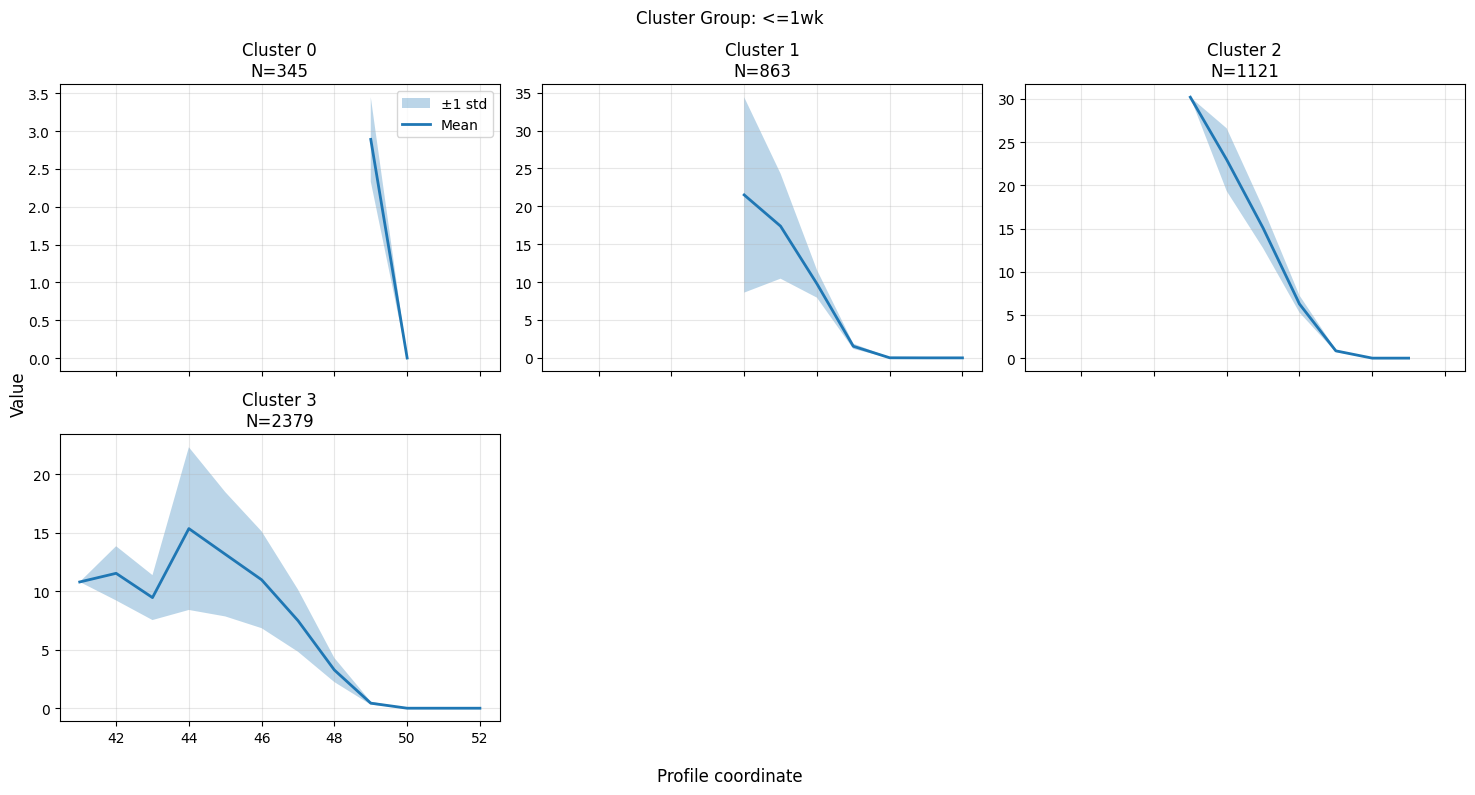

In [21]:
datapath = projectPath / "data" / "z_unnorm"

df = pd.read_parquet(projectPath / "data" / "ivdata.parquet")

for groupID, (groupLabel, group) in enumerate(df.groupby("Group")):
    keys = np.load(datapath / f"group_{groupID}_keys.npy", allow_pickle=True)
    labels = np.load(datapath / f"group_{groupID}_kmedoid_labels.npy")
    sliceMatrix = np.load(datapath / f"group_{groupID}_slices.npy")

    plotClusters(labels, sliceMatrix, groupLabel)

    break


In [19]:
np.unique(labels, return_counts=True)

(array([0], dtype=int32), array([4708]))